<a href="https://colab.research.google.com/github/sudhans18/ABDA/blob/main/05_Lexical_Diversity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

In [3]:
LC_PATH = "/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_linguistic_complexity_features_v2.pkl"

df_lex = pd.read_pickle(LC_PATH)

print("Shape:", df_lex.shape)
print("\nColumns:")
print(df_lex.columns.tolist())

display(df_lex.head())

Shape: (23253, 10)

Columns:
['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'word_count', 'avg_word_length', 'dependency_tree_depth', 'avg_dependency_distance']


,segment_id,label_idx,start,end,text,token_count,word_count,avg_word_length,dependency_tree_depth,avg_dependency_distance
0,--qXJuDtHPw,0,23.199,30.325,writer i see that a writer is somebody who has...,21,19,4.578947,9,1.722222
1,-3g5yACwYnA,0,82.753,100.555,key is part of the people that we use to solve...,49,42,4.642857,8,2.418605
2,-3g5yACwYnA,1,119.919,125.299,businesses that we do they've been able to fin...,23,19,4.368421,7,2.000000
3,-3g5yACwYnA,2,4.840,14.052,operations key polymer brings a technical aspe...,22,16,5.375000,4,3.235294
4,-3g5yACwYnA,3,13.211,27.521,internally we're a huge user of adhesives for ...,41,32,5.031250,4,2.781250


In [4]:
expected_lc_features = [
    "word_count",
    "avg_word_length",
    "dependency_tree_depth",
    "avg_dependency_distance"
]

missing_features = [
    col for col in expected_lc_features
    if col not in df_lex.columns
]

print("Missing expected features:", missing_features)

print("\nFeature dtypes:")
print(df_lex[expected_lc_features].dtypes)

print("\nMissing values:")
display(df_lex[expected_lc_features].isna().sum())

Missing expected features: []

Feature dtypes:
word_count                   int64
avg_word_length            float64
dependency_tree_depth        int64
avg_dependency_distance    float64
dtype: object

Missing values:


,0
word_count,0
avg_word_length,0
dependency_tree_depth,0
avg_dependency_distance,0


In [5]:
display(
    df_lex[
        ["segment_id", "text", "token_count", "word_count"]
    ].head(20)
)

,segment_id,text,token_count,word_count
0,--qXJuDtHPw,writer i see that a writer is somebody who has...,21,19
1,-3g5yACwYnA,key is part of the people that we use to solve...,49,42
2,-3g5yACwYnA,businesses that we do they've been able to fin...,23,19
3,-3g5yACwYnA,operations key polymer brings a technical aspe...,22,16
4,-3g5yACwYnA,internally we're a huge user of adhesives for ...,41,32
5,-3g5yACwYnA,of things key brings those types of aspects to...,39,36
6,-3g5yACwYnA,solutions we have many new opportunities throu...,26,24
7,-3nNcZdcdvU,introduction speaker dr erma jean sims sonoma ...,40,32
8,-3nNcZdcdvU,it's important for teachers to understand thei...,20,16
9,-3nNcZdcdvU,noncompliance can result in legal liability to...,23,18


In [6]:
print(df_lex["word_count"].describe())

print("\nWord-count quantiles:")
display(
    df_lex["word_count"]
    .quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame("word_count")
)

count    23253.000000
mean        21.122952
std         12.474859
min          1.000000
25%         13.000000
50%         18.000000
75%         26.000000
max        194.000000
Name: word_count, dtype: float64

Word-count quantiles:


,word_count
0.01,4.0
0.05,7.0
0.10,9.0
0.25,13.0
0.50,18.0
0.75,26.0
0.90,36.0
0.95,45.0
0.99,64.0


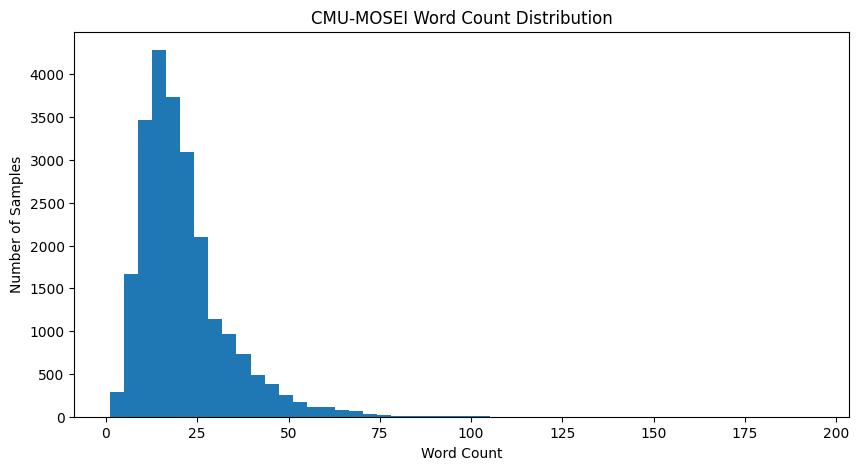

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_lex["word_count"],
    bins=50
)

plt.xlabel("Word Count")
plt.ylabel("Number of Samples")
plt.title("CMU-MOSEI Word Count Distribution")
plt.show()

In [9]:
def lexical_tokens(text):
    if not isinstance(text, str):
        return []

    tokens = re.findall(r"\b[\w']+\b", text.lower())

    return tokens

In [10]:
df_lex["lexical_tokens"] = df_lex["text"].apply(lexical_tokens)

df_lex["lexical_token_count"] = df_lex["lexical_tokens"].apply(len)

display(
    df_lex[
        ["text", "word_count", "lexical_token_count"]
    ].head(20)
)

,text,word_count,lexical_token_count
0,writer i see that a writer is somebody who has...,19,19
1,key is part of the people that we use to solve...,42,42
2,businesses that we do they've been able to fin...,19,19
3,operations key polymer brings a technical aspe...,16,16
4,internally we're a huge user of adhesives for ...,32,32
5,of things key brings those types of aspects to...,36,36
6,solutions we have many new opportunities throu...,24,24
7,introduction speaker dr erma jean sims sonoma ...,32,32
8,it's important for teachers to understand thei...,16,16
9,noncompliance can result in legal liability to...,18,18


In [11]:
token_diff = (
    df_lex["lexical_token_count"] - df_lex["word_count"]
)

print("Number of samples with different counts:", (token_diff != 0).sum())
print("Percentage different:", (token_diff != 0).mean() * 100)

print("\nDifference distribution:")
display(token_diff.describe())

Number of samples with different counts: 0
Percentage different: 0.0

Difference distribution:


,0
count,23253.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [13]:
df_lex["unique_word_count"] = (
    df_lex["lexical_tokens"]
    .apply(lambda tokens: len(set(tokens)))
)

display(
    df_lex[
        ["text", "lexical_token_count", "unique_word_count"]
    ].head(20)
)

,text,lexical_token_count,unique_word_count
0,writer i see that a writer is somebody who has...,19,17
1,key is part of the people that we use to solve...,42,34
2,businesses that we do they've been able to fin...,19,18
3,operations key polymer brings a technical aspe...,16,16
4,internally we're a huge user of adhesives for ...,32,29
5,of things key brings those types of aspects to...,36,28
6,solutions we have many new opportunities throu...,24,20
7,introduction speaker dr erma jean sims sonoma ...,32,22
8,it's important for teachers to understand thei...,16,16
9,noncompliance can result in legal liability to...,18,15


In [14]:
df_lex["ttr"] = np.where(
    df_lex["lexical_token_count"] > 0,
    df_lex["unique_word_count"] / df_lex["lexical_token_count"],
    np.nan
)

display(
    df_lex[
        ["text", "lexical_token_count", "unique_word_count", "ttr"]
    ].head(20)
)

,text,lexical_token_count,unique_word_count,ttr
0,writer i see that a writer is somebody who has...,19,17,0.894737
1,key is part of the people that we use to solve...,42,34,0.809524
2,businesses that we do they've been able to fin...,19,18,0.947368
3,operations key polymer brings a technical aspe...,16,16,1.000000
4,internally we're a huge user of adhesives for ...,32,29,0.906250
5,of things key brings those types of aspects to...,36,28,0.777778
6,solutions we have many new opportunities throu...,24,20,0.833333
7,introduction speaker dr erma jean sims sonoma ...,32,22,0.687500
8,it's important for teachers to understand thei...,16,16,1.000000
9,noncompliance can result in legal liability to...,18,15,0.833333


In [15]:
print("Unique word count:")
print(df_lex["unique_word_count"].describe())

print("\nTTR:")
print(df_lex["ttr"].describe())

print("\nInvalid TTR values:")
print(
    ((df_lex["ttr"] < 0) | (df_lex["ttr"] > 1)).sum()
)

print("\nMissing TTR values:")
print(df_lex["ttr"].isna().sum())

Unique word count:
count    23253.000000
mean        18.126005
std          8.987827
min          1.000000
25%         12.000000
50%         17.000000
75%         22.000000
max        109.000000
Name: unique_word_count, dtype: float64

TTR:
count    23253.000000
mean         0.891446
std          0.095551
min          0.222222
25%          0.833333
50%          0.904762
75%          1.000000
max          1.000000
Name: ttr, dtype: float64

Invalid TTR values:
0

Missing TTR values:
0


In [16]:
lexical_candidates = [
    "unique_word_count",
    "ttr"
]

correlation_results = []

for feature in lexical_candidates:
    valid = df_lex[["word_count", feature]].dropna()

    pearson_r, pearson_p = pearsonr(
        valid["word_count"],
        valid[feature]
    )

    spearman_r, spearman_p = spearmanr(
        valid["word_count"],
        valid[feature]
    )

    correlation_results.append({
        "feature": feature,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

lexical_length_corr = pd.DataFrame(correlation_results)

display(lexical_length_corr)

,feature,pearson_r,pearson_p,spearman_r,spearman_p
0,unique_word_count,0.972370,0.0,0.980441,0.0
1,ttr,-0.590607,0.0,-0.590236,0.0


In [17]:
bins = [0, 5, 10, 20, 40, 80, np.inf]
labels = ["1–5", "6–10", "11–20", "21–40", "41–80", "81+"]

df_lex["length_bin"] = pd.cut(
    df_lex["word_count"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

ttr_by_length = (
    df_lex
    .groupby("length_bin", observed=True)
    .agg(
        n=("ttr", "count"),
        mean_ttr=("ttr", "mean"),
        std_ttr=("ttr", "std"),
        median_ttr=("ttr", "median"),
        mean_unique_words=("unique_word_count", "mean")
    )
)

display(ttr_by_length)

,n,mean_ttr,std_ttr,median_ttr,mean_unique_words
length_bin,,,,,
1–5,538,0.981599,0.067147,1.000000,3.884758
6–10,2995,0.957308,0.075305,1.000000,8.058097
11–20,9911,0.918751,0.079886,0.933333,14.125214
21–40,8157,0.855927,0.080791,0.863636,23.316415
41–80,1596,0.758399,0.076097,0.761905,38.404762
81+,56,0.635918,0.063877,0.635754,67.482143


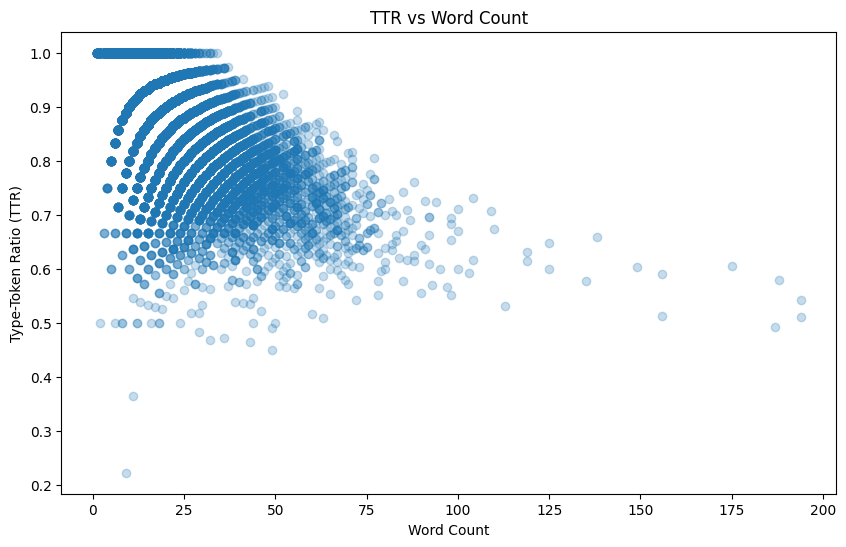

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_lex["word_count"],
    df_lex["ttr"],
    alpha=0.25
)

plt.xlabel("Word Count")
plt.ylabel("Type-Token Ratio (TTR)")
plt.title("TTR vs Word Count")
plt.show()

In [19]:
def msttr(tokens, segment_size=10):
    if len(tokens) < segment_size:
        return np.nan

    n_segments = len(tokens) // segment_size

    ttr_values = []

    for i in range(n_segments):
        segment = tokens[
            i * segment_size :
            (i + 1) * segment_size
        ]

        if len(segment) == 0:
            continue

        types = len(set(segment))
        tokens_count = len(segment)

        ttr_values.append(types / tokens_count)

    if not ttr_values:
        return np.nan

    return np.mean(ttr_values)

In [20]:
df_lex["msttr_10"] = df_lex["lexical_tokens"].apply(
    lambda x: msttr(x, segment_size=10)
)

print("Valid MSTTR samples:", df_lex["msttr_10"].notna().sum())
print("Missing MSTTR samples:", df_lex["msttr_10"].isna().sum())

display(
    df_lex[
        ["word_count", "ttr", "msttr_10"]
    ].head(20)
)

Valid MSTTR samples: 20579
Missing MSTTR samples: 2674


,word_count,ttr,msttr_10
0,19,0.894737,0.900000
1,42,0.809524,0.950000
2,19,0.947368,1.000000
3,16,1.000000,1.000000
4,32,0.906250,1.000000
5,36,0.777778,0.900000
6,24,0.833333,1.000000
7,32,0.687500,0.933333
8,16,1.000000,1.000000
9,18,0.833333,0.900000


In [22]:
df_lex["msttr_10"] = df_lex["lexical_tokens"].apply(
    lambda x: msttr(x, segment_size=10)
)

print("Valid MSTTR samples:", df_lex["msttr_10"].notna().sum())
print("Missing MSTTR samples:", df_lex["msttr_10"].isna().sum())

display(
    df_lex[
        ["word_count", "ttr", "msttr_10"]
    ].head(20)
)

Valid MSTTR samples: 20579
Missing MSTTR samples: 2674


,word_count,ttr,msttr_10
0,19,0.894737,0.900000
1,42,0.809524,0.950000
2,19,0.947368,1.000000
3,16,1.000000,1.000000
4,32,0.906250,1.000000
5,36,0.777778,0.900000
6,24,0.833333,1.000000
7,32,0.687500,0.933333
8,16,1.000000,1.000000
9,18,0.833333,0.900000


In [23]:
msttr_valid_pct = (
    df_lex["msttr_10"].notna().mean() * 100
)

print(f"Valid MSTTR samples: {msttr_valid_pct:.2f}%")

Valid MSTTR samples: 88.50%


In [24]:
print(df_lex["msttr_10"].describe())

count    20579.000000
mean         0.951668
std          0.062058
min          0.300000
25%          0.900000
50%          0.966667
75%          1.000000
max          1.000000
Name: msttr_10, dtype: float64


In [25]:
candidate_features = [
    "word_count",
    "unique_word_count",
    "ttr",
    "msttr_10"
]

display(
    df_lex[candidate_features]
    .corr(method="pearson")
)

,word_count,unique_word_count,ttr,msttr_10
word_count,1.000000,0.972370,-0.590607,-0.027006
unique_word_count,0.972370,1.000000,-0.447348,0.091141
ttr,-0.590607,-0.447348,1.000000,0.563672
msttr_10,-0.027006,0.091141,0.563672,1.000000


In [26]:
display(
    df_lex[candidate_features]
    .corr(method="spearman")
)

,word_count,unique_word_count,ttr,msttr_10
word_count,1.000000,0.980441,-0.590236,-0.151398
unique_word_count,0.980441,1.000000,-0.440798,-0.016804
ttr,-0.590236,-0.440798,1.000000,0.607905
msttr_10,-0.151398,-0.016804,0.607905,1.000000


In [27]:
unique_by_length = (
    df_lex
    .groupby("length_bin", observed=True)
    .agg(
        n=("unique_word_count", "count"),
        mean_words=("word_count", "mean"),
        mean_unique_words=("unique_word_count", "mean"),
        median_unique_words=("unique_word_count", "median"),
        std_unique_words=("unique_word_count", "std")
    )
)

display(unique_by_length)

,n,mean_words,mean_unique_words,median_unique_words,std_unique_words
length_bin,,,,,
1–5,538,3.966543,3.884758,4.0,1.213560
6–10,2995,8.427045,8.058097,8.0,1.393022
11–20,9911,15.418928,14.125214,14.0,2.637875
21–40,8157,27.410568,23.316415,23.0,4.210096
41–80,1596,50.972431,38.404762,37.0,6.223352
81+,56,107.892857,67.482143,63.5,15.135739


<Figure size 1000x600 with 0 Axes>

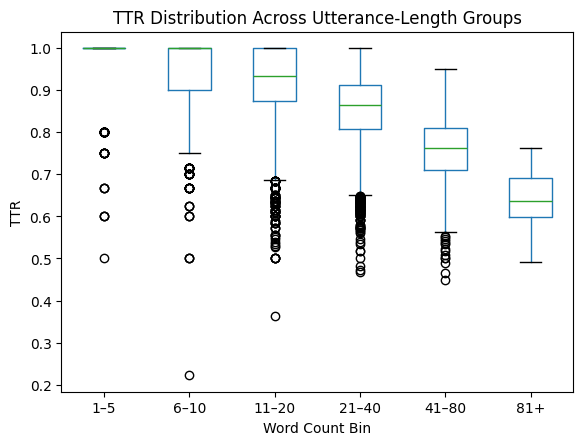

In [29]:
plt.figure(figsize=(10, 6))

df_lex.boxplot(
    column="ttr",
    by="length_bin",
    grid=False
)

plt.xlabel("Word Count Bin")
plt.ylabel("TTR")
plt.title("TTR Distribution Across Utterance-Length Groups")
plt.suptitle("")
plt.show()

In [30]:
df_lex["unique_to_token_ratio"] = np.where(
    df_lex["lexical_token_count"] > 0,
    df_lex["unique_word_count"] /
    df_lex["lexical_token_count"],
    np.nan
)

print(
    "Difference between TTR and unique_to_token_ratio:",
    np.nanmax(
        np.abs(
            df_lex["ttr"] -
            df_lex["unique_to_token_ratio"]
        )
    )
)

Difference between TTR and unique_to_token_ratio: 0.0


In [31]:
print(
    df_lex[
        ["token_count", "word_count", "lexical_token_count"]
    ].corr(method="pearson")
)

                     token_count  word_count  lexical_token_count
token_count             1.000000    0.984862             0.984862
word_count              0.984862    1.000000             1.000000
lexical_token_count     0.984862    1.000000             1.000000


In [32]:
candidate_summary = pd.DataFrame({
    "feature": [
        "unique_word_count",
        "ttr",
        "msttr_10"
    ],
    "valid_count": [
        df_lex["unique_word_count"].notna().sum(),
        df_lex["ttr"].notna().sum(),
        df_lex["msttr_10"].notna().sum()
    ],
    "missing_count": [
        df_lex["unique_word_count"].isna().sum(),
        df_lex["ttr"].isna().sum(),
        df_lex["msttr_10"].isna().sum()
    ],
    "mean": [
        df_lex["unique_word_count"].mean(),
        df_lex["ttr"].mean(),
        df_lex["msttr_10"].mean()
    ],
    "std": [
        df_lex["unique_word_count"].std(),
        df_lex["ttr"].std(),
        df_lex["msttr_10"].std()
    ]
})

display(candidate_summary)

,feature,valid_count,missing_count,mean,std
0,unique_word_count,23253,0,18.126005,8.987827
1,ttr,23253,0,0.891446,0.095551
2,msttr_10,20579,2674,0.951668,0.062058


In [33]:
lexical_candidate_df = df_lex[
    [
        "segment_id",
        "label_idx",
        "start",
        "end",
        "text",
        "word_count",
        "lexical_token_count",
        "unique_word_count",
        "ttr",
        "msttr_10"
    ]
].copy()

print("Shape:", lexical_candidate_df.shape)

display(lexical_candidate_df.head())

Shape: (23253, 10)


,segment_id,label_idx,start,end,text,word_count,lexical_token_count,unique_word_count,ttr,msttr_10
0,--qXJuDtHPw,0,23.199,30.325,writer i see that a writer is somebody who has...,19,19,17,0.894737,0.90
1,-3g5yACwYnA,0,82.753,100.555,key is part of the people that we use to solve...,42,42,34,0.809524,0.95
2,-3g5yACwYnA,1,119.919,125.299,businesses that we do they've been able to fin...,19,19,18,0.947368,1.00
3,-3g5yACwYnA,2,4.840,14.052,operations key polymer brings a technical aspe...,16,16,16,1.000000,1.00
4,-3g5yACwYnA,3,13.211,27.521,internally we're a huge user of adhesives for ...,32,32,29,0.906250,1.00


In [35]:
print("Missing values:")
display(
    lexical_candidate_df.isna().sum()
)

print("Duplicate (segment_id, label_idx) pairs:")
print(
    df_lex.duplicated(
        subset=["segment_id", "label_idx"]
    ).sum()
)

Missing values:


,0
segment_id,0
label_idx,0
start,0
end,0
text,0
word_count,0
lexical_token_count,0
unique_word_count,0
ttr,0
msttr_10,2674


Duplicate (segment_id, label_idx) pairs:
0


In [36]:
# Compare samples with and without valid MSTTR

msttr_groups = (
    df_lex
    .assign(
        msttr_available=df_lex["msttr_10"].notna()
    )
    .groupby("msttr_available")
    .agg(
        n=("word_count", "count"),
        mean_word_count=("word_count", "mean"),
        median_word_count=("word_count", "median"),
        min_word_count=("word_count", "min"),
        max_word_count=("word_count", "max"),
        mean_ttr=("ttr", "mean"),
        median_ttr=("ttr", "median")
    )
)

display(msttr_groups)

,n,mean_word_count,median_word_count,min_word_count,max_word_count,mean_ttr,median_ttr
msttr_available,,,,,,,
False,2674,7.024308,7.0,1,9,0.964936,1.000000
True,20579,22.954905,20.0,10,194,0.881897,0.896552


In [37]:
short_length_distribution = (
    df_lex[df_lex["msttr_10"].isna()]
    ["word_count"]
    .value_counts()
    .sort_index()
)

display(short_length_distribution)

,count
word_count,
1,32
2,50
3,68
4,142
5,246
6,340
7,477
8,601
9,718


In [38]:
length_summary = (
    df_lex
    .groupby(pd.cut(
        df_lex["word_count"],
        bins=[0, 5, 9, 19, 39, 79, np.inf],
        labels=["1–5", "6–9", "10–19", "20–39", "40–79", "80+"]
    ))
    .agg(
        n=("word_count", "count"),
        mean_word_count=("word_count", "mean"),
        mean_ttr=("ttr", "mean"),
        msttr_available=("msttr_10", lambda x: x.notna().mean())
    )
)

length_summary["percentage"] = (
    length_summary["n"] / len(df_lex) * 100
)

display(length_summary)

/tmp/ipykernel_2489/3392227496.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.cut(


,n,mean_word_count,mean_ttr,msttr_available,percentage
word_count,,,,,
1–5,538,3.966543,0.981599,0.0,2.313680
6–9,2136,7.794476,0.960739,0.0,9.185911
10–19,9907,14.550015,0.923306,1.0,42.605255
20–39,8882,26.494934,0.860760,1.0,38.197222
40–79,1730,50.030058,0.761810,1.0,7.439900
80+,60,106.033333,0.636024,1.0,0.258031


In [39]:
msttr_by_length = (
    df_lex[df_lex["msttr_10"].notna()]
    .groupby(pd.cut(
        df_lex["word_count"],
        bins=[9, 19, 39, 79, np.inf],
        labels=["10–19", "20–39", "40–79", "80+"]
    ))
    .agg(
        n=("msttr_10", "count"),
        mean_word_count=("word_count", "mean"),
        mean_msttr=("msttr_10", "mean"),
        median_msttr=("msttr_10", "median"),
        std_msttr=("msttr_10", "std")
    )
)

display(msttr_by_length)

/tmp/ipykernel_2489/2719603915.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.cut(


,n,mean_word_count,mean_msttr,median_msttr,std_msttr
word_count,,,,,
10–19,9907,14.550015,0.952740,1.000000,0.073664
20–39,8882,26.494934,0.951342,0.950000,0.050601
40–79,1730,50.030058,0.947482,0.950000,0.039258
80+,60,106.033333,0.943624,0.944444,0.027503


In [40]:

def msttr_with_remainder(tokens, segment_size=10):
    if len(tokens) < segment_size:
        return np.nan

    ttr_values = []

    for i in range(0, len(tokens), segment_size):
        segment = tokens[i:i + segment_size]

        if len(segment) == 0:
            continue

        # Include the final partial segment
        types = len(set(segment))
        ttr_values.append(types / len(segment))

    return np.mean(ttr_values)


df_lex["msttr_10_v2"] = df_lex["lexical_tokens"].apply(
    msttr_with_remainder
)

comparison = df_lex[
    ["word_count", "msttr_10", "msttr_10_v2"]
].copy()

comparison["difference"] = (
    comparison["msttr_10_v2"] - comparison["msttr_10"]
)

display(comparison.head(20))

print(
    "Valid MSTTR-10:",
    df_lex["msttr_10"].notna().sum()
)

print(
    "Valid MSTTR-10 v2:",
    df_lex["msttr_10_v2"].notna().sum()
)

print(
    "Mean absolute difference:",
    comparison["difference"].abs().mean()
)

print(
    "Maximum absolute difference:",
    comparison["difference"].abs().max()
)

,word_count,msttr_10,msttr_10_v2,difference
0,19,0.900000,0.894444,-0.005556
1,42,0.950000,0.960000,0.010000
2,19,1.000000,1.000000,0.000000
3,16,1.000000,1.000000,0.000000
4,32,1.000000,1.000000,0.000000
5,36,0.900000,0.925000,0.025000
6,24,1.000000,1.000000,0.000000
7,32,0.933333,0.950000,0.016667
8,16,1.000000,1.000000,0.000000
9,18,0.900000,0.950000,0.050000


Valid MSTTR-10: 20579
Valid MSTTR-10 v2: 20579
Mean absolute difference: 0.01925999101273325
Maximum absolute difference: 0.35000000000000003


In [41]:

diff_df = df_lex[
    ["segment_id", "label_idx", "text",
     "word_count", "lexical_token_count",
     "msttr_10", "msttr_10_v2"]
].copy()

diff_df["difference"] = (
    diff_df["msttr_10_v2"] - diff_df["msttr_10"]
)

# Show the largest differences
largest_diffs = (
    diff_df
    .dropna(subset=["difference"])
    .assign(abs_difference=lambda x: x["difference"].abs())
    .sort_values("abs_difference", ascending=False)
    .head(20)
)

display(largest_diffs)

,segment_id,label_idx,text,word_count,lexical_token_count,msttr_10,msttr_10_v2,difference,abs_difference
9181,8i7u3fl-hP8,1,men men men men men manly men men men the simp...,11,11,0.3,0.65,0.35,0.35
8245,70420,14,it over and over and over and over again and i...,18,18,0.4,0.70,0.30,0.30
22092,vwUBtNvjrU4,0,when you're working with you're working with y...,12,12,0.4,0.70,0.30,0.30
20172,o4b7hjQwpv0,0,every tournament will pick a different provinc...,12,12,1.0,0.75,-0.25,0.25
5323,270665,15,round and round same thing over and over and o...,12,12,0.5,0.75,0.25,0.25
16601,b1LEcg6z66g,5,the pupil premium is already making a big diff...,12,12,1.0,0.75,-0.25,0.25
2582,215259,9,movie but on the overall uhh i was kinda disap...,12,12,1.0,0.75,-0.25,0.25
370,0FA32bEZ6xI,22,mccarty keep up on the latest stamp news by fo...,12,12,1.0,0.75,-0.25,0.25
14029,S9PDgK7fpJI,1,we need it we need water we need supplies we n...,12,12,0.5,0.75,0.25,0.25
6565,367576,13,more a lot more and a lot more hacking and sla...,18,18,0.5,0.75,0.25,0.25


In [42]:

valid_msttr = df_lex[
    ["word_count", "msttr_10"]
].dropna()

pearson_msttr, pearson_p = pearsonr(
    valid_msttr["word_count"],
    valid_msttr["msttr_10"]
)

spearman_msttr, spearman_p = spearmanr(
    valid_msttr["word_count"],
    valid_msttr["msttr_10"]
)

print(f"Pearson correlation:  {pearson_msttr:.6f}")
print(f"Pearson p-value:      {pearson_p:.6e}")
print(f"Spearman correlation: {spearman_msttr:.6f}")
print(f"Spearman p-value:     {spearman_p:.6e}")

Pearson correlation:  -0.027006
Pearson p-value:      1.068181e-04
Spearman correlation: -0.151398
Spearman p-value:     8.991447e-106


## Lexical Diversity Feature Selection

Three lexical-diversity measures were evaluated: unique word count, Type-Token Ratio (TTR), and Moving-Average Type-Token Ratio (MSTTR-10).

Unique word count showed a very strong dependence on utterance length (Pearson r = 0.9724; Spearman ρ = 0.9804), making it unsuitable as a standalone lexical-diversity feature.

Raw TTR also showed substantial dependence on utterance length (Pearson r = -0.5906; Spearman ρ = -0.5902). TTR decreased systematically as utterance length increased, indicating that comparisons between utterances of different lengths could be strongly affected by sample size.

MSTTR-10 was therefore evaluated as a length-stabilized alternative. For each utterance containing at least 10 lexical tokens, the tokens are divided into complete non-overlapping blocks of 10 tokens. TTR is calculated within each complete block and the block-level values are averaged. Any incomplete remainder block is excluded.

MSTTR-10 showed substantially weaker dependence on utterance length (Pearson r = -0.0270; Spearman ρ = -0.1514) compared with raw TTR. Although the associations remain statistically significant due to the large sample size, their practical magnitude is much smaller.

Therefore, MSTTR-10 is selected as the final lexical-diversity feature for the ABDA pipeline.

## MSTTR-10 Remainder Handling

Two implementations of MSTTR-10 were compared.

The original implementation uses only complete 10-token blocks and ignores any incomplete remainder. A second implementation included the final remainder block when its length was less than 10 tokens.

The remainder-inclusive implementation produced a mean absolute difference of 0.0193 from the original MSTTR-10 and a maximum difference of 0.35. These differences occur because the shorter remainder block receives equal weight when averaging with complete 10-token blocks. Consequently, a small number of tokens can have a disproportionately large influence on the final score.

For methodological consistency, the complete-block implementation is retained. Therefore, MSTTR-10 is calculated only from complete 10-token blocks, while utterances containing fewer than 10 lexical tokens receive a missing value (NaN).

## Lexical Diversity Missingness and Limitations

MSTTR-10 is structurally unavailable for utterances containing fewer than 10 lexical tokens. In the current dataset, 2,674 of 23,253 samples (11.5%) fall below this threshold.

This missingness is expected from the definition of the fixed-size MSTTR-10 measure and is not treated as a preprocessing error. Missing MSTTR-10 values are therefore preserved as NaN rather than being replaced with zero or another arbitrary value.

The lexical-diversity analysis is applied to temporally reconstructed CMU-MOSEI segments rather than guaranteed complete sentences. Consequently, MSTTR-10 should be interpreted as a quantitative lexical-pattern feature of each reconstructed segment rather than as a direct measure of a person's psychological state, language ability, or clinical condition.

The final feature is intended for integration with the other ABDA behavioral modalities and should not be interpreted independently as evidence of emotional or mental-health status.

In [43]:
# ============================================================
# FINAL LEXICAL DIVERSITY FEATURE VALIDATION
# ============================================================

# Final selected feature
FINAL_LEXICAL_FEATURE = "msttr_10"

# Check that the feature exists
assert FINAL_LEXICAL_FEATURE in df_lex.columns, \
    f"Missing final feature: {FINAL_LEXICAL_FEATURE}"

# Check that the feature is within the expected [0, 1] range
valid_msttr_values = df_lex[FINAL_LEXICAL_FEATURE].dropna()

assert len(valid_msttr_values) > 0, "No valid MSTTR-10 values found."
assert valid_msttr_values.between(0, 1).all(), \
    "MSTTR-10 contains values outside [0, 1]."

# Check uniqueness of the row identifier
duplicate_keys = df_lex.duplicated(
    subset=["segment_id", "label_idx"]
).sum()

assert duplicate_keys == 0, \
    f"Found {duplicate_keys} duplicate (segment_id, label_idx) keys."

# Missingness
total_samples = len(df_lex)
missing_msttr = df_lex[FINAL_LEXICAL_FEATURE].isna().sum()
valid_msttr = df_lex[FINAL_LEXICAL_FEATURE].notna().sum()

print("Final lexical feature:", FINAL_LEXICAL_FEATURE)
print("Total samples:", total_samples)
print("Valid MSTTR-10:", valid_msttr)
print("Missing MSTTR-10:", missing_msttr)
print("Missing percentage:", round(100 * missing_msttr / total_samples, 2), "%")

print("\nMSTTR-10 statistics:")
display(df_lex[FINAL_LEXICAL_FEATURE].describe())

print("\nDuplicate (segment_id, label_idx) keys:", duplicate_keys)

print("\nFinal validation: PASSED")

Final lexical feature: msttr_10
Total samples: 23253
Valid MSTTR-10: 20579
Missing MSTTR-10: 2674
Missing percentage: 11.5 %

MSTTR-10 statistics:


,msttr_10
count,20579.000000
mean,0.951668
std,0.062058
min,0.300000
25%,0.900000
50%,0.966667
75%,1.000000
max,1.000000



Duplicate (segment_id, label_idx) keys: 0

Final validation: PASSED


In [44]:
# ============================================================
# SAVE FINAL LEXICAL DIVERSITY FEATURE ARTIFACT
# ============================================================

FINAL_LEXICAL_PATH = (
    "/content/drive/MyDrive/cmu_mosei/"
    "CMU_MOSEI_lexical_diversity_features.pkl"
)

# Columns required for downstream integration and traceability
final_lexical_columns = [
    "segment_id",
    "label_idx",
    "start",
    "end",
    "text",
    "word_count",
    "msttr_10"
]

# Verify all required columns exist
missing_final_columns = [
    col for col in final_lexical_columns
    if col not in df_lex.columns
]

assert not missing_final_columns, \
    f"Missing columns: {missing_final_columns}"

# Create clean final artifact
df_lexical_final = df_lex[final_lexical_columns].copy()

# Save
df_lexical_final.to_pickle(FINAL_LEXICAL_PATH)

print("Final lexical diversity artifact saved successfully.")
print("Path:", FINAL_LEXICAL_PATH)
print("Shape:", df_lexical_final.shape)
print("\nColumns:")
print(df_lexical_final.columns.tolist())

Final lexical diversity artifact saved successfully.
Path: /content/drive/MyDrive/cmu_mosei/CMU_MOSEI_lexical_diversity_features.pkl
Shape: (23253, 7)

Columns:
['segment_id', 'label_idx', 'start', 'end', 'text', 'word_count', 'msttr_10']
